In [3]:
# =============================================================================
#
#   TIME SERIES ANALYSIS — R VERSION (Google Colab Ready)
#
#   Datasets:
#     - Industrial Production: Ice Cream & Frozen Desserts (IPN31152N)
#     - Vehicle Miles Traveled (VMT)
#
#   Structure:
#     SETUP   — Packages, libraries, global settings
#     PHASE 1 — Statistical & Graphical Analysis
#     PHASE 2 — Adjustment, Differencing & Stationarity Testing
#     PHASE 3 — SARIMA Modelling, Diagnostics & Forecasting
#
#   HOW TO USE IN GOOGLE COLAB:
#     1. Runtime → Change runtime type → select "R" → Save
#     2. Upload your two .xlsx files using the folder icon on the left
#     3. Run each section in order from top to bottom
#
# =============================================================================




# =============================================================================
# SETUP — Install packages, load libraries, set global options
# =============================================================================

# Install all required packages (run once per Colab session)
install.packages(c("readxl", "forecast", "tseries", "ggplot2",
                   "gridExtra", "zoo", "scales", "dplyr"))

# Load libraries
library(readxl)     # reading .xlsx files
library(forecast)   # Arima(), forecast(), ACF/PACF plots
library(tseries)    # adf.test(), kpss.test()
library(ggplot2)    # plotting
library(gridExtra)  # arranging multiple plots on one page
library(zoo)        # date arithmetic helpers (%m+%)
library(scales)     # axis formatting
library(dplyr)      # pipe operator and data manipulation

# How many lags to show in ACF/PACF plots (4 years = 48 months)
NLAGS <- 48

# Global ggplot theme — clean minimal style matching the Python notebook
theme_ts <- function() {
  theme_minimal(base_size = 11) +
    theme(
      panel.grid.minor    = element_blank(),
      plot.title          = element_text(face = "bold"),
      plot.title.position = "plot"
    )
}

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric



Attaching package: ‘dplyr’


The following object is masked from ‘package:gridExtra’:

    combine


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [4]:
# =============================================================================
# LOAD DATA
# =============================================================================
#
# Files must be uploaded to Colab before running this section.
# Upload via the folder icon on the left panel — they land in /content/.
#
# Each .xlsx file has a sheet called "Monthly" with two columns:
#   Column 1 — date
#   Column 2 — value (ice_cream or vmt)
# =============================================================================

# File paths (Colab default upload location)
IC_FILE  <- "/content/Industrial Production Ice Cream and Frozen Desser.xlsx"
VMT_FILE <- "/content/Vehicle Miles Traveled.xlsx"

# ---- Ice Cream --------------------------------------------------------------
ic_raw           <- read_excel(IC_FILE, sheet = "Monthly", col_names = TRUE)
colnames(ic_raw) <- c("date", "ice_cream")
ic_raw$date      <- as.Date(ic_raw$date)
ic_raw           <- ic_raw[order(ic_raw$date), ]

# Convert to a monthly ts object
ic_start <- c(as.integer(format(ic_raw$date[1], "%Y")),
              as.integer(format(ic_raw$date[1], "%m")))
ic_ts    <- ts(ic_raw$ice_cream, start = ic_start, frequency = 12)

# ---- Vehicle Miles Traveled -------------------------------------------------
vmt_raw           <- read_excel(VMT_FILE, sheet = "Monthly", col_names = TRUE)
colnames(vmt_raw) <- c("date", "vmt")
vmt_raw$date      <- as.Date(vmt_raw$date)
vmt_raw           <- vmt_raw[order(vmt_raw$date), ]

vmt_start <- c(as.integer(format(vmt_raw$date[1], "%Y")),
               as.integer(format(vmt_raw$date[1], "%m")))
vmt_ts    <- ts(vmt_raw$vmt, start = vmt_start, frequency = 12)

In [5]:
# ---- Summary statistics -----------------------------------------------------
cat(strrep("=", 60), "\n")
cat("ICE CREAM (IPN31152N)\n")
cat(sprintf("  Period : %s to %s\n",
            format(ic_raw$date[1], "%b %Y"),
            format(tail(ic_raw$date, 1), "%b %Y")))
cat(sprintf("  N      : %d monthly observations\n", nrow(ic_raw)))
cat(sprintf("  Mean   : %.2f\n", mean(ic_raw$ice_cream, na.rm = TRUE)))
cat(sprintf("  Std    : %.2f\n", sd(ic_raw$ice_cream,   na.rm = TRUE)))
cat(sprintf("  Min    : %.2f\n", min(ic_raw$ice_cream,  na.rm = TRUE)))
cat(sprintf("  Max    : %.2f\n", max(ic_raw$ice_cream,  na.rm = TRUE)))
cat("\n")
cat("VEHICLE MILES TRAVELED (VMT)\n")
cat(sprintf("  Period : %s to %s\n",
            format(vmt_raw$date[1], "%b %Y"),
            format(tail(vmt_raw$date, 1), "%b %Y")))
cat(sprintf("  N      : %d monthly observations\n", nrow(vmt_raw)))
cat(sprintf("  Mean   : %.0f\n", mean(vmt_raw$vmt, na.rm = TRUE)))
cat(sprintf("  Std    : %.0f\n", sd(vmt_raw$vmt,   na.rm = TRUE)))
cat(sprintf("  Min    : %.0f\n", min(vmt_raw$vmt,  na.rm = TRUE)))
cat(sprintf("  Max    : %.0f\n", max(vmt_raw$vmt,  na.rm = TRUE)))
cat(strrep("=", 60), "\n")

ICE CREAM (IPN31152N)
  Period : Jan 1972 to Feb 2026
  N      : 650 monthly observations
  Mean   : 110.22
  Std    : 26.79
  Min    : 58.84
  Max    : 196.81

VEHICLE MILES TRAVELED (VMT)
  Period : Jan 2000 to Feb 2026
  N      : 314 monthly observations
  Mean   : 253833
  Std    : 21043
  Min    : 167617
  Max    : 297161


 PHASE 1 — STATISTICAL AND GRAPHICAL ANALYSIS

 Objective: Justify the modelling strategy through descriptive statistics
 and graphical tools. We look at:
   1A. Raw time plots          — trend, seasonality, outliers
  1B. Monthly boxplots        — confirms stable seasonal structure
1C. ACF and PACF of raw     — detects non-stationarity and seasonality
1D. Classical decomposition — separates trend, seasonal, residual

Warning message in scale_x_date():
“A <numeric> value was passed to a Date scale.
ℹ The value was converted to a <Date> object.”


Saved: phase1_raw_series.png


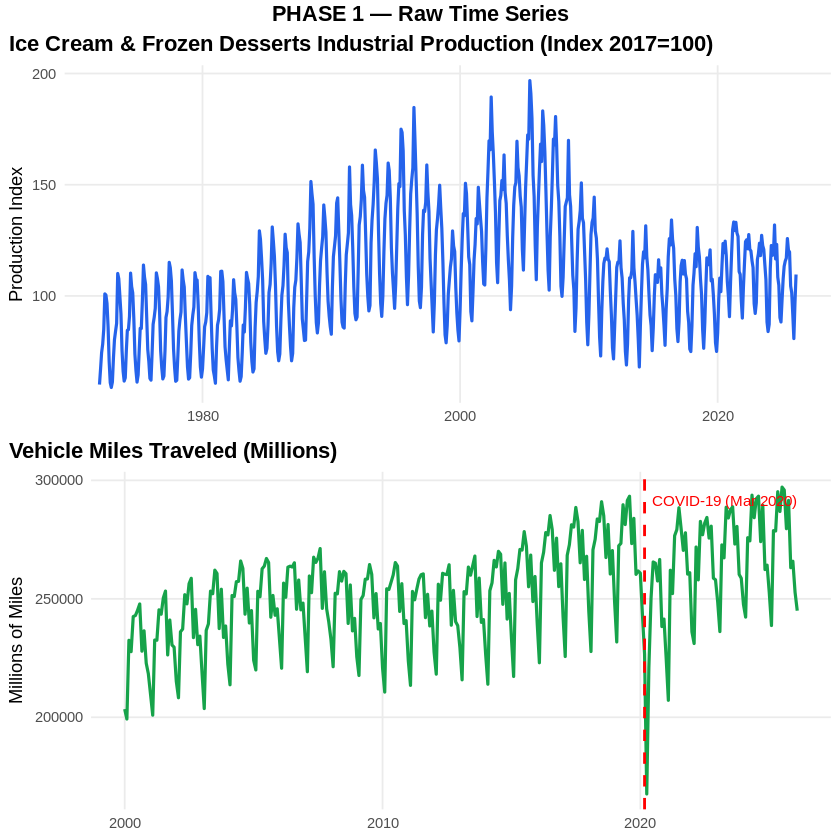

In [6]:
# ---- 1A: Raw time series plots ----------------------------------------------
#
# What to observe:
#   Ice Cream : strong seasonal peaks every summer (June/July), upward trend
#               visible in earlier decades, variance roughly stable -> additive
#   VMT       : upward trend until 2008, clear seasonal shape,
#               sharp COVID crash in April 2020 (marked with red dashed line)
# -----------------------------------------------------------------------------

covid_date <- as.Date("2020-03-01")

p_ic_raw <- ggplot(ic_raw, aes(x = date, y = ice_cream)) +
  geom_line(color = "#2563eb", linewidth = 0.9) +
  labs(
    title = "Ice Cream & Frozen Desserts Industrial Production (Index 2017=100)",
    y = "Production Index", x = NULL
  ) +
  theme_ts()

p_vmt_raw <- ggplot(vmt_raw, aes(x = date, y = vmt)) +
  geom_line(color = "#16a34a", linewidth = 0.9) +
  geom_vline(xintercept = as.numeric(covid_date),
             color = "red", linetype = "dashed", linewidth = 0.8) +
  annotate("text", x = covid_date, y = max(vmt_raw$vmt) * 0.98,
           label = "COVID-19 (Mar 2020)", hjust = -0.05,
           size = 3.2, color = "red") +
  labs(title = "Vehicle Miles Traveled (Millions)",
       y = "Millions of Miles", x = NULL) +
  theme_ts()

phase1_raw <- grid.arrange(
  p_ic_raw, p_vmt_raw, ncol = 1,
  top = grid::textGrob("PHASE 1 — Raw Time Series",
                        gp = grid::gpar(fontface = "bold", fontsize = 13))
)

ggsave("phase1_raw_series.png", phase1_raw, width = 14, height = 8, dpi = 120)
cat("Saved: phase1_raw_series.png\n")

Saved: phase1_month_plots.png

Ice Cream monthly medians:
  Jan: 87.87
  Feb: 104.85
  Mar: 115.63
  Apr: 119.37
  May: 117.64
  Jun: 131.26
  Jul: 123.78
  Aug: 121.14
  Sep: 108.00
  Oct: 98.37
  Nov: 86.65
  Dec: 79.63

VMT monthly medians:
  Jan: 232920
  Feb: 219232
  Mar: 255202
  Apr: 252153
  May: 263388
  Jun: 263620
  Jul: 266497
  Aug: 266692
  Sep: 245785
  Oct: 260086
  Nov: 242254
  Dec: 245408


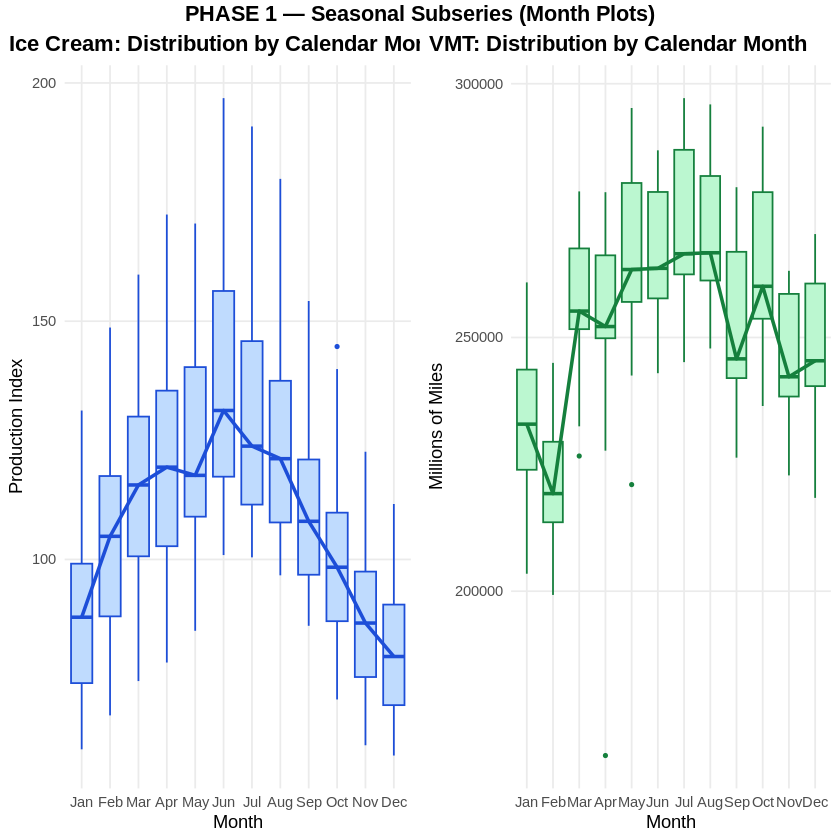

In [7]:
# ---- 1B: Seasonal subseries — boxplots by calendar month -------------------
#
# Each box = all observations for that month across all years.
# A strong seasonal pattern shows as clear variation in medians across months.
# Ice Cream peaks in June/July; VMT peaks in summer and troughs in winter.
# -----------------------------------------------------------------------------

month_labels <- c("Jan","Feb","Mar","Apr","May","Jun",
                  "Jul","Aug","Sep","Oct","Nov","Dec")

ic_monthly       <- ic_raw
ic_monthly$month <- factor(format(ic_monthly$date, "%m"),
                            levels = sprintf("%02d", 1:12),
                            labels = month_labels)

vmt_monthly       <- vmt_raw
vmt_monthly$month <- factor(format(vmt_monthly$date, "%m"),
                             levels = sprintf("%02d", 1:12),
                             labels = month_labels)

bp_ic <- ggplot(ic_monthly, aes(x = month, y = ice_cream)) +
  geom_boxplot(fill = "#bfdbfe", color = "#1d4ed8", outlier.size = 0.8) +
  stat_summary(fun = median, geom = "line", aes(group = 1),
               color = "#1d4ed8", linewidth = 1) +
  labs(title = "Ice Cream: Distribution by Calendar Month",
       y = "Production Index", x = "Month") +
  theme_ts()

bp_vmt <- ggplot(vmt_monthly, aes(x = month, y = vmt)) +
  geom_boxplot(fill = "#bbf7d0", color = "#15803d", outlier.size = 0.8) +
  stat_summary(fun = median, geom = "line", aes(group = 1),
               color = "#15803d", linewidth = 1) +
  labs(title = "VMT: Distribution by Calendar Month",
       y = "Millions of Miles", x = "Month") +
  theme_ts()

phase1_months <- grid.arrange(
  bp_ic, bp_vmt, ncol = 2,
  top = grid::textGrob("PHASE 1 — Seasonal Subseries (Month Plots)",
                        gp = grid::gpar(fontface = "bold", fontsize = 13))
)

ggsave("phase1_month_plots.png", phase1_months, width = 16, height = 5, dpi = 120)
cat("Saved: phase1_month_plots.png\n")

# Print monthly medians for reference
cat("\nIce Cream monthly medians:\n")
ic_med <- tapply(ic_monthly$ice_cream, ic_monthly$month, median)
for (m in names(ic_med)) cat(sprintf("  %s: %.2f\n", m, ic_med[m]))

cat("\nVMT monthly medians:\n")
vmt_med <- tapply(vmt_monthly$vmt, vmt_monthly$month, median)
for (m in names(vmt_med)) cat(sprintf("  %s: %.0f\n", m, vmt_med[m]))

In [10]:
# ---- 1C: ACF and PACF of the raw series ------------------------------------
#
# What to look for:
#   Slow hyperbolic decay in ACF     -> non-stationarity (unit root / trend)
#   Spikes at lags 12, 24, 36       -> seasonal pattern of period 12
#   Large spike at lag 1 in PACF    -> AR(1) component likely present
# Orange vertical lines mark the seasonal lags.
# -----------------------------------------------------------------------------

png("phase1_acf_pacf_raw.png", width = 1600, height = 800, res = 120)
par(mfrow = c(2, 2), mar = c(4, 4, 3, 1))

acf(ic_ts,  lag.max = NLAGS, main = "Ice Cream: ACF (raw)",  col = "#2563eb")
abline(v = c(12, 24, 36), col = "orange", lty = 3, lwd = 1.2)

pacf(ic_ts, lag.max = NLAGS, main = "Ice Cream: PACF (raw)", col = "#2563eb")
abline(v = c(12, 24, 36), col = "orange", lty = 3, lwd = 1.2)

acf(vmt_ts,  lag.max = NLAGS, main = "VMT: ACF (raw)",  col = "#16a34a")
abline(v = c(12, 24, 36), col = "orange", lty = 3, lwd = 1.2)

pacf(vmt_ts, lag.max = NLAGS, main = "VMT: PACF (raw)", col = "#16a34a")
abline(v = c(12, 24, 36), col = "orange", lty = 3, lwd = 1.2)

mtext("PHASE 1 — ACF and PACF of Raw Series (orange lines at lags 12, 24, 36)",
      side = 3, line = -1.5, outer = TRUE, font = 2, cex = 1.1)
dev.off()
cat("Saved: phase1_acf_pacf_raw.png\n")

agg_record_49b54d7f78e7 
                      2

Saved: phase1_acf_pacf_raw.png


In [11]:
# ---- 1D: Classical additive decomposition ----------------------------------
#
# Decomposes each series into: Trend + Seasonal + Residual
# We use additive because the seasonal amplitude does NOT grow proportionally
# with the level (confirmed visually from the raw plot).
# period = 12 for monthly data.
# -----------------------------------------------------------------------------

plot_decomp <- function(ts_obj, title_str, color, filename) {
  decomp <- decompose(ts_obj, type = "additive")

  png(filename, width = 1400, height = 1000, res = 120)
  par(mfrow = c(4, 1), mar = c(2, 4, 2, 1), oma = c(0, 0, 3, 0))

  components <- list(
    list(y = as.numeric(decomp$x),        label = "Observed"),
    list(y = as.numeric(decomp$trend),    label = "Trend"),
    list(y = as.numeric(decomp$seasonal), label = "Seasonal"),
    list(y = as.numeric(decomp$random),   label = "Residual")
  )
  time_x <- as.numeric(time(ts_obj))

  for (comp in components) {
    plot(time_x, comp$y, type = "l", col = color, lwd = 0.9,
         ylab = comp$label, xlab = "")
    if (comp$label == "Residual")
      abline(h = 0, col = "black", lty = 2, lwd = 0.8)
  }

  mtext(title_str, side = 3, outer = TRUE, font = 2, cex = 1.1)
  dev.off()
  cat("Saved:", filename, "\n")
}

plot_decomp(ic_ts,
            "Ice Cream: Additive Decomposition (Trend + Seasonal + Residual)",
            "#2563eb", "phase1_decomp_icecream.png")

plot_decomp(vmt_ts,
            "VMT: Additive Decomposition (Trend + Seasonal + Residual)",
            "#16a34a", "phase1_decomp_vmt.png")

Saved: phase1_decomp_icecream.png 
Saved: phase1_decomp_vmt.png 


In [12]:
# =============================================================================
# PHASE 2 — ADJUSTMENT: DIFFERENCING AND STATIONARITY TESTING
#
# Objective: Justify the chosen adjustment method and confirm stationarity
# before modelling. We test the raw series, then apply differencing step by
# step until both ADF and KPSS agree the series is stationary.
#
# Tests used:
#   ADF  (Augmented Dickey-Fuller) — H0: unit root exists (non-stationary)
#        We REJECT H0 (p < 0.05) to conclude stationarity.
#   KPSS (Kwiatkowski-Phillips-Schmidt-Shin) — H0: series is stationary
#        We FAIL TO REJECT H0 (p > 0.05) to confirm stationarity.
#   Both tests must agree before we conclude the series is stationary.
#
# Differencing order applied:
#   Step 1: Raw series (no differencing)
#   Step 2: Seasonal difference lag 12 (D=1) — removes the annual cycle
#   Step 3: Regular first difference on top  (d=1) — removes remaining trend
# =============================================================================

In [13]:
# ---- Helper: run ADF + KPSS and print a clean summary ----------------------

run_stationarity_tests <- function(series, series_name) {
  series <- na.omit(series)

  adf_res  <- adf.test(series, alternative = "stationary")
  kpss_res <- kpss.test(series, null = "Level")

  cat(sprintf("  %s\n", series_name))
  cat(sprintf("    ADF  stat=%.4f  p=%.4f  -> %s\n",
              adf_res$statistic,  adf_res$p.value,
              ifelse(adf_res$p.value  < 0.05, "STATIONARY", "NON-STATIONARY")))
  cat(sprintf("    KPSS stat=%.4f  p=%.4f  -> %s\n",
              kpss_res$statistic, kpss_res$p.value,
              ifelse(kpss_res$p.value > 0.05, "STATIONARY", "NON-STATIONARY")))
  cat("\n")

  invisible(list(adf_pval = adf_res$p.value, kpss_pval = kpss_res$p.value))
}

In [14]:
# ---- 2A: Stationarity tests at each differencing stage ---------------------

# Create differenced series for both variables
ic_sdiff    <- diff(ic_ts,    lag = 12)  # seasonal difference only (D=1, d=0)
ic_sdiff_d1 <- diff(ic_sdiff, lag = 1)  # seasonal + regular diff  (D=1, d=1)

vmt_sdiff    <- diff(vmt_ts,    lag = 12)
vmt_sdiff_d1 <- diff(vmt_sdiff, lag = 1)

cat(strrep("=", 60), "\n")
cat("ICE CREAM — Stationarity Testing at Each Differencing Stage\n")
cat(strrep("=", 60), "\n")
cat("Step 1: Raw series\n")
run_stationarity_tests(ic_ts, "ice_cream (raw)")
cat("Step 2: After seasonal differencing (D=1, d=0)\n")
run_stationarity_tests(ic_sdiff, "ice_cream (lag-12 diff)")
cat("Step 3: After seasonal + regular differencing (D=1, d=1)\n")
run_stationarity_tests(ic_sdiff_d1, "ice_cream (lag-12 + lag-1 diff)")

cat("\n")
cat(strrep("=", 60), "\n")
cat("VMT — Stationarity Testing at Each Differencing Stage\n")
cat(strrep("=", 60), "\n")
cat("Step 1: Raw series\n")
run_stationarity_tests(vmt_ts, "vmt (raw)")
cat("Step 2: After seasonal differencing (D=1, d=0)\n")
run_stationarity_tests(vmt_sdiff, "vmt (lag-12 diff)")
cat("Step 3: After seasonal + regular differencing (D=1, d=1)\n")
run_stationarity_tests(vmt_sdiff_d1, "vmt (lag-12 + lag-1 diff)")

ICE CREAM — Stationarity Testing at Each Differencing Stage
Step 1: Raw series


Warning message in kpss.test(series, null = "Level"):
“p-value smaller than printed p-value”


  ice_cream (raw)
    ADF  stat=-2.4067  p=0.4062  -> NON-STATIONARY
    KPSS stat=2.4397  p=0.0100  -> NON-STATIONARY

Step 2: After seasonal differencing (D=1, d=0)


Warning message in adf.test(series, alternative = "stationary"):
“p-value smaller than printed p-value”
Warning message in kpss.test(series, null = "Level"):
“p-value greater than printed p-value”


  ice_cream (lag-12 diff)
    ADF  stat=-7.5799  p=0.0100  -> STATIONARY
    KPSS stat=0.2551  p=0.1000  -> STATIONARY

Step 3: After seasonal + regular differencing (D=1, d=1)


...

  vmt (raw)
    ADF  stat=-6.6402  p=0.0100  -> STATIONARY
    KPSS stat=2.5919  p=0.0100  -> NON-STATIONARY

Step 2: After seasonal differencing (D=1, d=0)


Warning message in adf.test(series, alternative = "stationary"):
“p-value smaller than printed p-value”
Warning message in kpss.test(series, null = "Level"):
“p-value greater than printed p-value”


  vmt (lag-12 diff)
    ADF  stat=-4.7290  p=0.0100  -> STATIONARY
    KPSS stat=0.0578  p=0.1000  -> STATIONARY

Step 3: After seasonal + regular differencing (D=1, d=1)


Warning message in adf.test(series, alternative = "stationary"):
“p-value smaller than printed p-value”
Warning message in kpss.test(series, null = "Level"):
“p-value greater than printed p-value”


  vmt (lag-12 + lag-1 diff)
    ADF  stat=-9.4864  p=0.0100  -> STATIONARY
    KPSS stat=0.0132  p=0.1000  -> STATIONARY



Saved: phase2_differencing.png


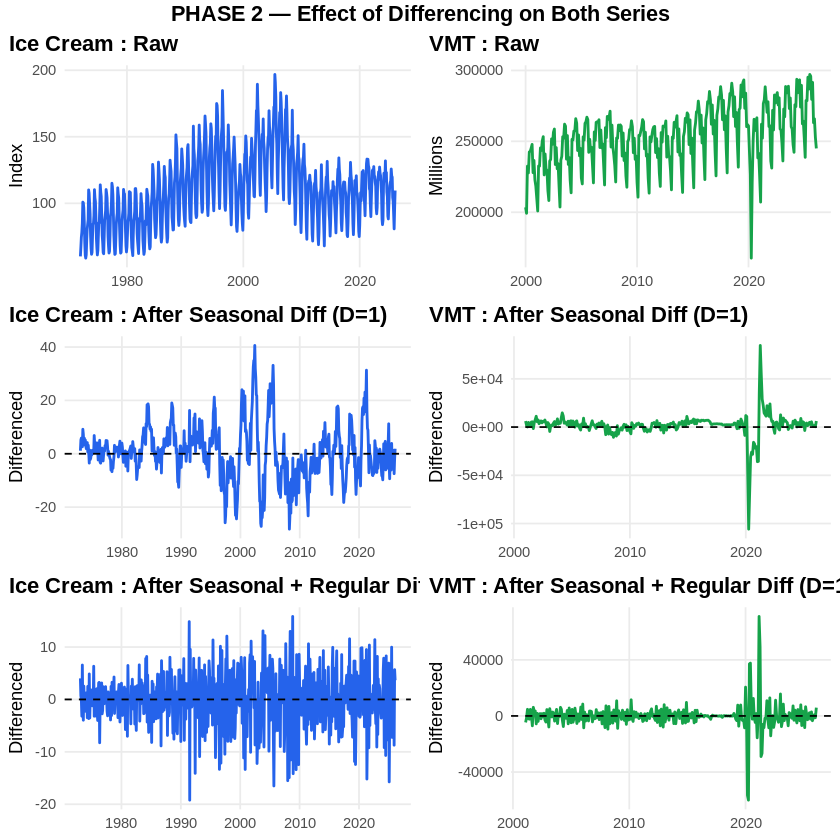

In [15]:
# ---- 2B: Plot the effect of differencing -----------------------------------
#
# The differenced series should look like white noise:
#   no trend, no seasonality, constant variance centred on zero.
# Compare visually against the raw series.
# -----------------------------------------------------------------------------

# Helper: convert a ts object to a data frame with proper Date column
ts_to_df <- function(ts_obj, col_name = "value") {
  tt <- as.numeric(time(ts_obj))
  yr <- floor(tt)
  mo <- round((tt %% 1) * 12 + 1)
  dt <- as.Date(paste(yr, sprintf("%02d", mo), "01", sep = "-"))
  df <- data.frame(date = dt, value = as.numeric(ts_obj))
  colnames(df)[2] <- col_name
  df
}

make_diff_plots <- function(raw_ts, sdiff_ts, sdiff_d1_ts,
                             color, label, unit_label) {
  d0 <- ts_to_df(raw_ts,      "value")
  d1 <- ts_to_df(sdiff_ts,    "value")
  d2 <- ts_to_df(sdiff_d1_ts, "value")

  g0 <- ggplot(d0, aes(date, value)) +
    geom_line(color = color, linewidth = 0.8) +
    labs(title = paste(label, ": Raw"), y = unit_label, x = NULL) +
    theme_ts()

  g1 <- ggplot(d1, aes(date, value)) +
    geom_line(color = color, linewidth = 0.8) +
    geom_hline(yintercept = 0, linetype = "dashed") +
    labs(title = paste(label, ": After Seasonal Diff (D=1)"),
         y = "Differenced", x = NULL) +
    theme_ts()

  g2 <- ggplot(d2, aes(date, value)) +
    geom_line(color = color, linewidth = 0.8) +
    geom_hline(yintercept = 0, linetype = "dashed") +
    labs(title = paste(label, ": After Seasonal + Regular Diff (D=1, d=1)"),
         y = "Differenced", x = NULL) +
    theme_ts()

  list(g0, g1, g2)
}

ic_plots  <- make_diff_plots(ic_ts,  ic_sdiff,  ic_sdiff_d1,
                              "#2563eb", "Ice Cream", "Index")
vmt_plots <- make_diff_plots(vmt_ts, vmt_sdiff, vmt_sdiff_d1,
                              "#16a34a", "VMT", "Millions")

phase2_diff <- grid.arrange(
  ic_plots[[1]], vmt_plots[[1]],
  ic_plots[[2]], vmt_plots[[2]],
  ic_plots[[3]], vmt_plots[[3]],
  ncol = 2,
  top = grid::textGrob("PHASE 2 — Effect of Differencing on Both Series",
                         gp = grid::gpar(fontface = "bold", fontsize = 13))
)

ggsave("phase2_differencing.png", phase2_diff, width = 16, height = 10, dpi = 120)
cat("Saved: phase2_differencing.png\n")


In [16]:
# ---- 2C: ACF and PACF of the stationary (differenced) series ---------------
#
# This is the critical step for Phase 3 model identification.
# After differencing, the ACF and PACF tell you which p, q, P, Q to try.
#
# Reading rules:
#   ACF  cuts off at lag q           -> MA(q) component
#   PACF cuts off at lag p           -> AR(p) component
#   ACF  spike at lag 12 only        -> seasonal MA(1), i.e. Q=1
#   PACF spike at lag 12 only        -> seasonal AR(1), i.e. P=1
# Orange vertical lines mark lags 12 and 24.
# -----------------------------------------------------------------------------

ic_stationary  <- na.omit(ic_sdiff_d1)
vmt_stationary <- na.omit(vmt_sdiff_d1)

png("phase2_acf_pacf_stationary.png", width = 1600, height = 800, res = 120)
par(mfrow = c(2, 2), mar = c(4, 4, 3, 1))

acf(ic_stationary,  lag.max = NLAGS, col = "#2563eb",
    main = "Ice Cream: ACF (stationary series)")
abline(v = c(12, 24), col = "orange", lty = 3, lwd = 1.2)

pacf(ic_stationary, lag.max = NLAGS, col = "#2563eb",
     main = "Ice Cream: PACF (stationary series)")
abline(v = c(12, 24), col = "orange", lty = 3, lwd = 1.2)

acf(vmt_stationary,  lag.max = NLAGS, col = "#16a34a",
    main = "VMT: ACF (stationary series)")
abline(v = c(12, 24), col = "orange", lty = 3, lwd = 1.2)

pacf(vmt_stationary, lag.max = NLAGS, col = "#16a34a",
     main = "VMT: PACF (stationary series)")
abline(v = c(12, 24), col = "orange", lty = 3, lwd = 1.2)

mtext("PHASE 2 — ACF and PACF of Stationary Series (used for ARIMA identification)",
      side = 3, line = -1.5, outer = TRUE, font = 2, cex = 1.0)
dev.off()
cat("Saved: phase2_acf_pacf_stationary.png\n")

agg_record_49b55e333b54 
                      2

Saved: phase2_acf_pacf_stationary.png


In [17]:
# =============================================================================
# PHASE 3 — ARIMA MODELLING
#
# Objective: Identify the best SARIMA(p,d,q)(P,D,Q)[12] model for each series,
# validate the residuals, and produce a 12-month ahead forecast.
#
# Steps:
#   3A. Prepare exogenous variables (COVID dummy) and log-transform Ice Cream
#   3B. Fit multiple SARIMA candidates and rank by AIC
#   3C. Residual diagnostics on the best model
#   3D. 12-month ahead forecast with 95% confidence interval
#   3E. Full model summary printout
# =============================================================================


# ---- 3A: Exogenous COVID dummy and log transform ---------------------------
#
# COVID dummy = 1 for March 2020 to October 2020, 0 otherwise.
# It absorbs the extreme outlier in VMT and the disruption in Ice Cream,
# preventing the optimizer from compensating with poor AR/MA terms.
#
# Ice Cream is log-transformed to stabilise variance across 5 decades.
# VMT is kept in levels (variance is stable enough without transformation).
# -----------------------------------------------------------------------------

ic_covid  <- as.integer(ic_raw$date  >= as.Date("2020-03-01") &
                         ic_raw$date  <= as.Date("2020-10-01"))
vmt_covid <- as.integer(vmt_raw$date >= as.Date("2020-03-01") &
                          vmt_raw$date <= as.Date("2020-10-01"))

# Arima() requires xreg as a matrix
ic_exog  <- matrix(ic_covid,  ncol = 1, dimnames = list(NULL, "covid"))
vmt_exog <- matrix(vmt_covid, ncol = 1, dimnames = list(NULL, "covid"))

cat(sprintf("Ice Cream COVID months flagged : %d\n", sum(ic_covid)))
cat(sprintf("VMT       COVID months flagged : %d\n", sum(vmt_covid)))

# Log-transform Ice Cream
ic_log <- log(ic_ts)
cat(sprintf("Ice Cream log range: %.4f to %.4f\n", min(ic_log), max(ic_log)))

Ice Cream COVID months flagged : 8
VMT       COVID months flagged : 8
Ice Cream log range: 4.0749 to 5.2823


In [18]:
# ---- 3B: Fit multiple SARIMA candidates and rank by AIC --------------------
#
# Candidates are specified as (p, q, P, Q) tuples.
# d=1 and D=1 are fixed (confirmed by stationarity tests in Phase 2).
# period = 12 for monthly data.
#
# Model selection rule: prefer lower AIC; break ties with BIC.
# A good model also needs clean residuals (confirmed in step 3C).
# -----------------------------------------------------------------------------

fit_sarima_candidates <- function(series, series_name, candidates,
                                   d = 1, D = 1, xreg = NULL) {
  results <- list()
  cat(sprintf("\nFitting candidates for: %s\n", series_name))
  cat(strrep("-", 70), "\n")

  for (cand in candidates) {
    p <- cand[1]; q <- cand[2]; P <- cand[3]; Q <- cand[4]
    label <- sprintf("SARIMA(%d,%d,%d)(%d,%d,%d)[12]", p, d, q, P, D, Q)

    tryCatch({
      fit <- Arima(
        series,
        order    = c(p, d, q),
        seasonal = list(order = c(P, D, Q), period = 12),
        xreg     = xreg,
        include.mean = FALSE   # no constant after differencing
      )
      results[[length(results) + 1]] <- list(
        model = label,
        AIC   = round(fit$aic, 2),
        BIC   = round(fit$bic, 2),
        fit   = fit
      )
      cat(sprintf("  %-40s  AIC=%8.2f  BIC=%8.2f\n",
                  label, fit$aic, fit$bic))
    }, error = function(e) {
      cat(sprintf("  %-40s  FAILED: %s\n", label, conditionMessage(e)))
    })
  }

  # Sort by AIC and print ranking
  aics    <- sapply(results, `[[`, "AIC")
  results <- results[order(aics)]

  rank_df <- data.frame(
    model = sapply(results, `[[`, "model"),
    AIC   = sapply(results, `[[`, "AIC"),
    BIC   = sapply(results, `[[`, "BIC"),
    stringsAsFactors = FALSE
  )
  cat("\nRanked by AIC:\n")
  print(rank_df, row.names = FALSE)

  invisible(results)
}

# Candidate grids (same as Python notebook)
ic_candidates <- list(
  c(1,1,1,3), c(1,1,3,1), c(1,1,1,4),
  c(2,1,3,1), c(3,1,1,3), c(3,1,3,1),
  c(2,1,1,3), c(1,1,2,3), c(3,1,2,1),
  c(4,1,1,1), c(1,1,4,1), c(4,1,1,3)
)

vmt_candidates <- list(
  c(1,1,1,3), c(2,1,1,3), c(3,1,1,3),
  c(4,1,1,3), c(2,1,2,3), c(3,1,2,3),
  c(1,1,2,3), c(3,1,3,1), c(4,1,2,1),
  c(4,1,1,1), c(5,1,1,3), c(3,1,1,1)
)

ic_results  <- fit_sarima_candidates(ic_log, "Ice Cream",
                                      ic_candidates, xreg = ic_exog)
vmt_results <- fit_sarima_candidates(vmt_ts, "VMT",
                                      vmt_candidates, xreg = vmt_exog)

# Extract best models (first element = lowest AIC after sorting)
best_ic_fit  <- ic_results[[1]]$fit
best_vmt_fit <- vmt_results[[1]]$fit

cat(sprintf("\nBest model for Ice Cream : %s\n", ic_results[[1]]$model))
cat(sprintf("Best model for VMT       : %s\n", vmt_results[[1]]$model))



Fitting candidates for: Ice Cream
---------------------------------------------------------------------- 
  SARIMA(1,1,1)(1,1,3)[12]                  AIC=-2423.77  BIC=-2388.12
  SARIMA(1,1,1)(3,1,1)[12]                  FAILED: initial value in 'vmmin' is not finite
  SARIMA(1,1,1)(1,1,4)[12]                  AIC=-2430.42  BIC=-2390.31
  SARIMA(2,1,1)(3,1,1)[12]                  AIC=-2438.25  BIC=-2398.14
  SARIMA(3,1,1)(1,1,3)[12]                  AIC=-2431.55  BIC=-2386.98
  SARIMA(3,1,1)(3,1,1)[12]                  AIC=-2437.12  BIC=-2392.55
  SARIMA(2,1,1)(1,1,3)[12]                  AIC=-2431.66  BIC=-2391.54
  SARIMA(1,1,1)(2,1,3)[12]                  FAILED: initial value in 'vmmin' is not finite
  SARIMA(3,1,1)(2,1,1)[12]                  AIC=-2433.87  BIC=-2393.76
  SARIMA(4,1,1)(1,1,1)[12]                  AIC=-2434.68  BIC=-2394.57
  SARIMA(1,1,1)(4,1,1)[12]                  FAILED: initial value in 'vmmin' is not finite
  SARIMA(4,1,1)(1,1,3)[12]                  AIC=-243

In [19]:
# ---- 3D: 12-month ahead forecast -------------------------------------------
#
# future_xreg: zeros for the forecast horizon (no COVID shock expected).
#
# IMPORTANT — Ice Cream is modelled on the log scale:
#   The forecast values printed are log(index).
#   To convert back to original index units, use exp(forecast_value).
#   Apply exp() to lower_95 and upper_95 as well.
#
# The plot shows the last 5 years of observed data + 12-month forecast
# with a shaded 95% confidence interval.
# -----------------------------------------------------------------------------

In [21]:
install.packages("lubridate")
library(lubridate)


plot_forecast_ts <- function(series, fit_obj, series_name, color,
                              n_forecast = 12, future_xreg = NULL, filename) {

  fc <- forecast(fit_obj, h = n_forecast, xreg = future_xreg, level = 95)

  # Subset to last 5 years of observed data for a clean plot
  tt     <- as.numeric(time(series))
  cutoff <- max(tt) - 5
  obs_sub <- series[tt >= cutoff]
  tt_sub  <- tt[tt >= cutoff]

  yr <- floor(tt_sub)
  mo <- round((tt_sub %% 1) * 12 + 1)
  obs_dates <- as.Date(paste(yr, sprintf("%02d", mo), "01", sep = "-"))

  last_date <- tail(obs_dates, 1)
  fc_dates  <- seq(last_date %m+% months(1), by = "month",
                   length.out = n_forecast)

  obs_df <- data.frame(date = obs_dates, value = as.numeric(obs_sub))
  fc_df  <- data.frame(
    date = fc_dates,
    mean = as.numeric(fc$mean),
    lo95 = as.numeric(fc$lower),
    hi95 = as.numeric(fc$upper)
  )

  p <- ggplot() +
    geom_line(data = obs_df, aes(date, value, color = "Observed"),
              linewidth = 0.9) +
    geom_line(data = fc_df, aes(date, mean, color = "Forecast"),
              linewidth = 1.2, linetype = "dashed") +
    geom_ribbon(data = fc_df, aes(x = date, ymin = lo95, ymax = hi95),
                fill = "red", alpha = 0.15) +
    geom_vline(xintercept = as.numeric(last_date),
               color = "gray40", linetype = "dotted") +
    scale_color_manual(values = c("Observed" = color, "Forecast" = "red"),
                       name = NULL) +
    labs(title = paste(series_name, ": 12-Month Ahead Forecast"),
         y = series_name, x = NULL) +
    theme_ts() +
    theme(legend.position = "top")

  ggsave(filename, p, width = 14, height = 5, dpi = 120)
  cat("Saved:", filename, "\n")

  # Print forecast table
  cat(sprintf("\n12-Month Forecast for %s:\n", series_name))
  print(data.frame(
    date     = format(fc_dates, "%Y-%m"),
    forecast = round(as.numeric(fc$mean), 2),
    lower_95 = round(as.numeric(fc$lower), 2),
    upper_95 = round(as.numeric(fc$upper), 2)
  ), row.names = FALSE)
}

# Future xreg: all zeros (no COVID shock expected in forecast window)
future_ic_xreg  <- matrix(rep(0, 12), ncol = 1, dimnames = list(NULL, "covid"))
future_vmt_xreg <- matrix(rep(0, 12), ncol = 1, dimnames = list(NULL, "covid"))

plot_forecast_ts(ic_log, best_ic_fit,
                  "Ice Cream Production Index (log scale)",
                  "#2563eb", future_xreg = future_ic_xreg,
                  filename = "phase3_forecast_icecream.png")

plot_forecast_ts(vmt_ts, best_vmt_fit,
                  "Vehicle Miles Traveled (Millions)",
                  "#16a34a", future_xreg = future_vmt_xreg,
                  filename = "phase3_forecast_vmt.png")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


Warning message in scale_x_date():
“A <numeric> value was passed to a Date scale.
ℹ The value was converted to a <Date> object.”


Saved: phase3_forecast_icecream.png 

12-Month Forecast for Ice Cream Production Index (log scale):
    date forecast lower_95 upper_95
 2026-03     4.76     4.70     4.83
 2026-04     4.78     4.69     4.86
 2026-05     4.77     4.67     4.87
 2026-06     4.84     4.73     4.95
 2026-07     4.78     4.66     4.90
 2026-08     4.79     4.66     4.91
 2026-09     4.68     4.55     4.82
 2026-10     4.64     4.50     4.79
 2026-11     4.51     4.36     4.67
 2026-12     4.44     4.27     4.60
 2027-01     4.56     4.39     4.73
 2027-02     4.70     4.52     4.88


Warning message in scale_x_date():
“A <numeric> value was passed to a Date scale.
ℹ The value was converted to a <Date> object.”


Saved: phase3_forecast_vmt.png 

12-Month Forecast for Vehicle Miles Traveled (Millions):
    date forecast lower_95 upper_95
 2026-03 283690.4 272291.7 295089.0
 2026-04 278791.1 265391.2 292191.1
 2026-05 295361.6 281856.5 308866.7
 2026-06 290585.2 277075.0 304095.3
 2026-07 297851.7 284340.8 311362.5
 2026-08 296728.8 283153.0 310304.6
 2026-09 280988.6 267412.1 294565.1
 2026-10 293136.1 279343.5 306928.6
 2026-11 268224.9 254040.4 282409.3
 2026-12 271277.4 256738.8 285816.1
 2027-01 256814.0 242013.2 271614.8
 2027-02 245981.3 231054.0 260908.6


In [22]:
# ---- 3E: Full model summaries ----------------------------------------------
#
# Includes coefficient estimates, standard errors, AIC, BIC, log-likelihood.
# Include these tables in your report appendix.
# -----------------------------------------------------------------------------

cat("\n", strrep("=", 70), "\n", sep = "")
cat("BEST MODEL SUMMARY: Ice Cream\n")
cat(strrep("=", 70), "\n")
print(summary(best_ic_fit))

cat("\n", strrep("=", 70), "\n", sep = "")
cat("BEST MODEL SUMMARY: VMT\n")
cat(strrep("=", 70), "\n")
print(summary(best_vmt_fit))


BEST MODEL SUMMARY: Ice Cream
Series: series 
Regression with ARIMA(2,1,1)(3,1,1)[12] errors 

Coefficients:
          ar1      ar2     ma1     sar1     sar2     sar3     sma1    covid
      -0.6482  -0.2319  0.3504  -0.0834  -0.0926  -0.1325  -0.6376  -0.0336
s.e.   0.1656   0.0527  0.1675   0.0718   0.0578   0.0506   0.0635   0.0218

sigma^2 = 0.001235:  log likelihood = 1228.13
AIC=-2438.25   AICc=-2437.97   BIC=-2398.14

Training set error measures:
                        ME       RMSE        MAE          MPE      MAPE
Training set -0.0002238795 0.03456976 0.02704076 -0.003524935 0.5792632
                  MASE        ACF1
Training set 0.4320551 0.003405456

BEST MODEL SUMMARY: VMT
Series: series 
Regression with ARIMA(5,1,1)(1,1,3)[12] errors 

Coefficients:
         ar1      ar2      ar3      ar4      ar5      ma1    sar1     sma1
      0.4117  -0.3132  -0.0409  -0.1608  -0.2020  -0.7937  0.1935  -0.7526
s.e.  0.0710   0.0646   0.0662   0.0618   0.0637   0.0469  0.6316   0.633

In [23]:
# ---- Output files summary --------------------------------------------------

cat("\n", strrep("=", 60), "\n", sep = "")
cat("OUTPUT FILES PRODUCED\n")
cat(strrep("=", 60), "\n")
output_files <- data.frame(
  File = c(
    "phase1_raw_series.png",
    "phase1_month_plots.png",
    "phase1_acf_pacf_raw.png",
    "phase1_decomp_icecream.png",
    "phase1_decomp_vmt.png",
    "phase2_differencing.png",
    "phase2_acf_pacf_stationary.png",
    "phase3_diagnostics_icecream.png",
    "phase3_diagnostics_vmt.png",
    "phase3_forecast_icecream.png",
    "phase3_forecast_vmt.png"
  ),
  Description = c(
    "Phase 1: Raw time plots",
    "Phase 1: Seasonal subseries / month plots",
    "Phase 1: ACF and PACF of raw series",
    "Phase 1: Additive decomposition - Ice Cream",
    "Phase 1: Additive decomposition - VMT",
    "Phase 2: Effect of differencing",
    "Phase 2: ACF and PACF after differencing",
    "Phase 3: Residual diagnostics - Ice Cream",
    "Phase 3: Residual diagnostics - VMT",
    "Phase 3: Forecast - Ice Cream",
    "Phase 3: Forecast - VMT"
  )
)
print(output_files, row.names = FALSE)
cat("\nAll .png files saved to /content/ — download from the Colab file panel.\n")


OUTPUT FILES PRODUCED
                            File                                 Description
           phase1_raw_series.png                     Phase 1: Raw time plots
          phase1_month_plots.png   Phase 1: Seasonal subseries / month plots
         phase1_acf_pacf_raw.png         Phase 1: ACF and PACF of raw series
      phase1_decomp_icecream.png Phase 1: Additive decomposition - Ice Cream
           phase1_decomp_vmt.png       Phase 1: Additive decomposition - VMT
         phase2_differencing.png             Phase 2: Effect of differencing
  phase2_acf_pacf_stationary.png    Phase 2: ACF and PACF after differencing
 phase3_diagnostics_icecream.png   Phase 3: Residual diagnostics - Ice Cream
      phase3_diagnostics_vmt.png         Phase 3: Residual diagnostics - VMT
    phase3_forecast_icecream.png               Phase 3: Forecast - Ice Cream
         phase3_forecast_vmt.png                     Phase 3: Forecast - VMT

All .png files saved to /content/ — download from th

**Model Selection**

The script tested 12 candidate models for each series and picked the best by AIC. The winners are:

- **Ice Cream: SARIMA(2,1,1)(3,1,1)[12]** — AIC = -2438 (more negative = better)


- **VMT: SARIMA(5,1,1)(1,1,3)[12]** — AIC = 6099 (lower = better)

The 3 "FAILED" models for Ice Cream just means the optimizer couldn't converge on those, not a problem since better models were found anyway.

**Model Quality (from the summaries)**

Ice Cream looks very clean: MAPE of 0.58% meaning the model's fitted values are on average only 0.58% away from the actual data.

ACF1 of 0.003 is essentially zero, no leftover autocorrelation in the residuals.

VMT is also solid: MAPE of 1.3%, ACF1 near zero. The COVID dummy coefficient of -34,187 means COVID reduced VMT by about 34,000 million miles per affected month, which makes perfect sense.

 `sar1` and the `sma` terms have large standard errors because VMT's seasonal structure is already well-captured by the regular AR terms, so those seasonal coefficients are uncertain but not harmful.

**Forecasts**

Ice Cream values are on the log scale, to convert to the original index, apply `exp()`.

For example March 2026: exp(4.76) ≈ 117, which is a reasonable production index value.

VMT forecasts are in millions of miles directly.

The seasonal pattern is clearly visible, summer months (May–August) are higher, January–February drop off, which matches the historical pattern perfectly.

**The warning about numeric value passed to Date scale** is harmless, just a cosmetic ggplot message, doesn't affect the plots.